# Batch dataset: 9-condition re-render comparison + SH2/SH3 decomposition

Driver for the `batch_render_scenes.py` datasets (128 lights, conditions `env` / `env_ground`,
DC-lifted env maps). Two parts:

**A — forward re-render comparison.** Nine image sources per view:
- **GT re-renders** (GT intrinsics + GT lighting) with `ct_sh`, `ct_env` (quadrature),
  `ct_env` (GGX importance) — for `env` and `env_ground` → 6
- **Blender** renders: `env`, `env_ground` (no-shadow), `env_ground` (shadow) → 3

For **light 0** we save A / B / residual(A−B) panels (RMSE + MAE annotated) for the pairs
`ct_sh↔ct_env`, `ct_env↔ct_env(imp)`, `ct_sh↔Blender`, `ct_env↔Blender`, for both `env` and
`env_ground` (the Blender pairs on `env_ground` are done against no-shadow **and** shadow
separately). Mean±std of every pair metric over all views is reported.

**B — decomposition.** All 9 sources become datasets and are decomposed with **SH2** and **SH3**
(central `DOWNSAMPLE`, default ÷4). First 100 lights train, last 28 are the held-out
relighting val set. Per run we save: an intrinsics panel (target/recon/error + RMSE), one
relighting panel per val light (target/relit/residual + RMSE/MAE), and a `report.json`.
Everything is tracked on wandb. Final cell plots the metric means±std across views.

`ct_env` / `ct_env(imp)` decomposition is wired but disabled by default (`DECOMP_SHADERS`).

In [1]:
import os
import sys, os, json, types
from pathlib import Path
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Repo root, found by walking up from the CWD. Notebooks live in notebooks/, but the
# code and the relative data paths below are relative to the repo root, so chdir there.
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "idr").is_dir())
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

try:
    import wandb
    assert hasattr(wandb, 'init')
    WANDB_OK = True
except Exception:
    _stub = types.ModuleType('wandb')
    class _Run:
        def log(self, *a, **k): pass
        def finish(self): pass
    _stub.init = lambda **kw: _Run(); _stub.log = lambda *a, **k: None; _stub.Image = lambda *a, **k: None
    sys.modules['wandb'] = wandb = _stub
    WANDB_OK = False
    print('wandb stub (metrics still saved locally)')


from idr.data.build import build_3dfront_dataset
from idr.data.geometry import make_proxy_geometry
from idr.data.scene_io import load_exr
from idr.pipelines.decompose import decompose_scene, make_run_name
from idr.render import shade_ct_sh, shade_ct_env, EnvMap
from idr.render import build_sh_basis
from idr.render.brdf import _get_ggx_sh_lut

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
pd.set_option('display.width', 240)

# ── config ────────────────────────────────────────────────────────────────────
BATCH_ROOT   = Path(r'E:\3D-Front\output')
SCENE_FILTER = None            # e.g. ['00004f89']; None = all
MAX_VIEWS    = None            # cap (scene,view) pairs for testing; None = all
MAX_LIGHTS   = None            # truncate lights per view (testing); None = all
# DS_ROOT      = Path('results/3dfront-batch')
DS_ROOT      = Path(r'E:\3D-Front\results\3dfront-batch')

DOWNSAMPLE   = 1               # central resolution reduction for decomposition
N_TRAIN      = 100             # first N lights used for training
N_VAL        = 28              # remaining lights held out for relighting
# SH_ORDERS    = [2, 3]          # decomposition SH orders to compare
SH_ORDERS    = [2]          # decomposition SH orders to compare
DECOMP_SHADERS = ['ct_sh']     # ['ct_sh','ct_env','ct_env_imp'] — env variants off by default
SPEC_SAMPLES = 128
# Generate CT re-render datasets in BOTH diffuse-Fresnel modes so we can compare:
# frOn = data uses (1-F)(1-m) (matches the always-Fresnel-ON optimizer -> inverse
# crime, recon -> 0); frOff = data uses (1-m) (deliberate model mismatch).
# CT_FRESNEL_MODES = [True, False]
CT_FRESNEL_MODES = [True]

# ── which dataset versions to build per view (see dataset_specs) ──
CT_SHADERS    = ['ct_sh']                    # CT render shaders: 'ct_sh','ct_env','ct_env_imp'
CT_CONDS      = ['env', 'env_ground']        # CT lighting conditions ([] = no CT datasets)
BLENDER_CONDS = ['env', 'env_ground_shadow'] # blender: 'env','env_ground_noshadow','env_ground_shadow' ([] = none)

FORCE_RECHECK   = False        # redo part A
FORCE_DECOMPOSE = False        # redo part B

WANDB_PROJECT_A = '3dfront-rerender-compare'
WANDB_PROJECT_B = '3dfront-batch-decomposition'
WANDB_OK = False

DECOMP_BASE_CFG = {
    'n_iter': 600, 'lbfgs_max_iter': 40, 'log_every': 10,
    'lambda_tv': 1e-5, 'lambda_metallic_binarize': 0,
    'tr_metallic': 'sigmoid', 'tr_roughness': 'sigmoid', 'tr_albedo': 'sigmoid',
    'init_roughness_zero': True, 'double': True,
    'wandb_max_images': 6,     # cap per-image wandb previews (scalars use all imgs)
    'diffuse_fresnel': True,   # optimizer ALWAYS Fresnel-ON (== frOn CT data + blender)
}
ENV_STRENGTH = 2.0
print(f'device={DEVICE}  wandb={"ON" if WANDB_OK else "stub"}  downsample={DOWNSAMPLE}')

c:\Users\felix\miniconda3\envs\torch311\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


device=cuda  wandb=stub  downsample=1


In [2]:
# ── discovery: (scene, view) with GT dirs + Blender images + GT SH per light ───
def discover_views():
    views = []
    for sd in sorted(BATCH_ROOT.iterdir()):
        if not sd.is_dir() or sd.name.lower().startswith('backup'):
            continue
        if SCENE_FILTER and not any(sd.name.startswith(p) for p in SCENE_FILTER):
            continue
        for vd in sorted((p for p in sd.iterdir() if p.is_dir() and p.name.isdigit()),
                         key=lambda p: int(p.name)):
            acc = vd / 'accepted_setup.json'
            gdir = vd / 'ground'
            if not acc.exists() or not (gdir / 'albedo.png').exists():
                continue
            setup = json.loads(acc.read_text())
            env_e = setup.get('env'); grd_e = setup.get('env_ground')
            if not env_e or not grd_e:
                continue
            n = min(len(env_e), len(grd_e))
            if MAX_LIGHTS:
                n = min(n, MAX_LIGHTS)
            env_exr = [vd / f'env_{i}.exr' for i in range(n)]
            gnos    = [gdir / f'env_ground_noshadow_{i}.exr' for i in range(n)]
            gsha    = [gdir / f'env_ground_shadow_{i}.exr' for i in range(n)]
            if not (all(f.exists() for f in env_exr) and all(f.exists() for f in gnos)
                    and all(f.exists() for f in gsha)):
                continue
            def _sh(entries):
                out = []
                for e in entries[:n]:
                    p = Path(e['light_spec'][0]['path']); idx = p.stem.split('_')[-1]
                    out.append(np.load(p.parent / f'sh_{idx}.npy').astype(np.float32)
                               * float(e['light_spec'][0].get('strength', ENV_STRENGTH)))
                return out
            views.append(dict(
                scene=sd.name, view=int(vd.name), key=f'{sd.name[:8]}_v{vd.name}', n=n,
                env_dir=vd, ground_dir=gdir,
                blender={'env': env_exr, 'env_ground_noshadow': gnos, 'env_ground_shadow': gsha},
                sh_env=_sh(env_e), sh_ground=_sh(grd_e)))
    return views

views = discover_views()
if MAX_VIEWS:
    views = views[:MAX_VIEWS]
print(f'{len(views)} (scene, view) pair(s), {views[0]["n"] if views else 0} lights each:')
for v in views:
    print(f'  {v["key"]:20s} {v["n"]} lights')

67 (scene, view) pair(s), 128 lights each:
  1c349305_v0          128 lights
  1c349305_v1          128 lights
  1c349305_v2          128 lights
  1c349305_v3          128 lights
  1c349305_v4          128 lights
  1f19c3ef_v0          128 lights
  1f19c3ef_v1          128 lights
  1f19c3ef_v2          128 lights
  1f19c3ef_v3          128 lights
  1f19c3ef_v4          128 lights
  1f19c3ef_v5          128 lights
  29f1ce41_v0          128 lights
  29f1ce41_v1          128 lights
  29f1ce41_v2          128 lights
  29f1ce41_v3          128 lights
  29f1ce41_v4          128 lights
  3764dfa2_v0          128 lights
  3764dfa2_v1          128 lights
  3764dfa2_v2          128 lights
  3764dfa2_v3          128 lights
  3e038beb_v0          128 lights
  3e038beb_v1          128 lights
  3e038beb_v2          128 lights
  4d94c89f_v0          128 lights
  4d94c89f_v1          128 lights
  4d94c89f_v2          128 lights
  6cd50522_v0          128 lights
  6cd50522_v1          128 lights
  6cd

In [5]:
# ── per-view renderers (full res) ──────────────────────────────────────────────
def load_gt_view(d: Path, use_npy: bool = False) -> dict:
    if use_npy and (d / 'normals.npy').exists():
        n = np.load(d / 'normals.npy').astype(np.float32)
        mask = np.linalg.norm(n, axis=-1) > 0
        n /= np.maximum(np.linalg.norm(n, axis=-1, keepdims=True), 1e-6)
        rough = np.load(d / 'roughness.npy').astype(np.float32)
        metal = np.load(d / 'metallic.npy').astype(np.float32)
        return dict(normals=n, mask=mask,
                    albedo=np.load(d / 'albedo.npy').astype(np.float32)[:, :, :3],
                    rough=rough if rough.ndim == 3 else rough[:, :, None],
                    metal=metal if metal.ndim == 3 else metal[:, :, None])
    nr = np.array(Image.open(d / 'normals.png'), np.float32)
    mask = nr.sum(-1) > 0
    n = nr / 255 * 2 - 1
    n /= np.maximum(np.linalg.norm(n, axis=-1, keepdims=True), 1e-6)
    return dict(normals=n, mask=mask,
                albedo=np.array(Image.open(d / 'albedo.png'), np.float32)[:, :, :3] / 255,
                rough=(np.array(Image.open(d / 'roughness.png'), np.float32) / 65535.)[:, :, None],
                metal=(np.array(Image.open(d / 'metallic.png'), np.float32) / 65535.)[:, :, None])

class GTRenderer:
    def __init__(self, gt):
        self.gt = gt; self.H, self.W = gt['mask'].shape
        self.mflat = gt['mask'].reshape(-1)
        n_hw, f_hw, m_hw, cam = make_proxy_geometry(gt['normals'], gt['mask'],
                                                    device=DEVICE, dtype=torch.float64)
        fm = m_hw.reshape(-1)
        self.N = n_hw.reshape(-1, 3)[fm]
        self.V = torch.nn.functional.normalize(cam.unsqueeze(0) - f_hw.reshape(-1, 3)[fm], dim=-1)
        f = lambda a: torch.from_numpy(np.ascontiguousarray(a, np.float64)).to(DEVICE).reshape(-1, a.shape[-1])[fm]
        self.A, self.R, self.M = f(gt['albedo']), f(gt['rough']), f(gt['metal'])
        self.lut = _get_ggx_sh_lut(DEVICE, n_bands=3).double()
    def _scatter(self, flat):
        out = np.zeros((self.H * self.W, 3), np.float32)
        out[self.mflat] = flat.float().cpu().numpy()
        return out.reshape(self.H, self.W, 3)
    def render(self, sh, shader, diffuse_fresnel=True):
        with torch.no_grad():
            if shader == 'ct_sh':
                sh_t = torch.from_numpy(np.asarray(sh, np.float64)).to(DEVICE)
                o = shade_ct_sh(self.V, self.N, self.A, sh_t, metallic=self.M, roughness=self.R,
                                lut=self.lut, diffuse_fresnel=diffuse_fresnel)
            else:
                img = np.maximum(build_sh_basis(EnvMap._sh_grid_dirs(64)) @ np.asarray(sh, np.float32), 0.0)
                em = EnvMap(img)
                o = shade_ct_env(self.V, self.N, self.A,
                                 torch.from_numpy(em._image_flat).to(DEVICE, torch.float64),
                                 torch.from_numpy(em._dirs).to(DEVICE, torch.float64),
                                 torch.from_numpy(em._solid_angles).to(DEVICE, torch.float64),
                                 metallic=self.M, roughness=self.R,
                                 spec_importance=(shader == 'ct_env_imp'), spec_samples=SPEC_SAMPLES,
                                 diffuse_fresnel=diffuse_fresnel)
        return self._scatter(o)

def masked_errs(A, B, mask):
    d = (A - B)[mask]
    return float(np.sqrt((d ** 2).mean())), float(np.abs(d).mean())

## A — forward re-render comparison (light 0)

In [4]:
import itertools
# ── Part A: forward-render comparison at light 0 (all outputs SAVED to disk;
# no inline images, no wandb — just progress). Two products per view:
#   1) all-vs-all similarity (confusion) matrices  -> sim_<cond>_<rmse|mae>.png
#   2) pairwise A / B / residual panels            -> pair_<cond>__<A>__vs__<B>.png
# The averaged confusion matrices are shown in the next cell.
CONDS = {
    'env':        ['ct_sh_frOn', 'ct_sh_frOff', 'ct_env', 'ct_env_imp', 'blender'],
    'env_ground': ['ct_sh_frOn', 'ct_sh_frOff', 'ct_env', 'ct_env_imp',
                   'blender_noshadow', 'blender_shadow'],
}
# specific pairs to render as A/B/residual panels (per condition)
PAIRS = {
    'env': [('ct_sh_frOn', 'ct_sh_frOff'), ('ct_sh_frOn', 'ct_env'), ('ct_env', 'ct_env_imp'),
            ('ct_sh_frOn', 'blender'), ('ct_sh_frOff', 'blender'), ('ct_env', 'blender')],
    'env_ground': [('ct_sh_frOn', 'ct_sh_frOff'), ('ct_sh_frOn', 'ct_env'), ('ct_env', 'ct_env_imp')]
                  + [(a, b) for b in ('blender_noshadow', 'blender_shadow')
                     for a in ('ct_sh_frOn', 'ct_sh_frOff', 'ct_env')],
}

def _sim_matrix(variants, mask, metric):
    labels = list(variants); M = len(labels); mat = np.zeros((M, M))
    for i, j in itertools.combinations(range(M), 2):
        d = (variants[labels[i]] - variants[labels[j]])[mask]
        val = float(np.sqrt((d ** 2).mean())) if metric == 'rmse' else float(np.abs(d).mean())
        mat[i, j] = mat[j, i] = val
    return labels, mat

def _plot_matrix(ax, labels, mat, title):
    im = ax.imshow(mat, cmap='viridis')
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
    thr = mat.max() * 0.6 if mat.max() > 0 else 1
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f'{mat[i, j]:.3f}', ha='center', va='center', fontsize=7,
                    color='white' if mat[i, j] < thr else 'black')
    ax.set_title(title, fontsize=9); return im

def pair_panel(A, B, mask, nameA, nameB, title, save_path, tone=2.0):
    rmse, mae = masked_errs(A, B, mask); resid = np.abs(A - B).mean(-1) * mask
    fig, ax = plt.subplots(1, 3, figsize=(11, 3.8))
    ax[0].imshow(np.clip(A / tone, 0, 1)); ax[0].set_title(nameA, fontsize=9)
    ax[1].imshow(np.clip(B / tone, 0, 1)); ax[1].set_title(nameB, fontsize=9)
    im = ax[2].imshow(resid, cmap='inferno'); ax[2].set_title(f'|A-B|  RMSE={rmse:.4f}  MAE={mae:.4f}', fontsize=9)
    plt.colorbar(im, ax=ax[2], fraction=0.046)
    for a in ax: a.axis('off')
    fig.suptitle(title, fontsize=10); plt.tight_layout()
    fig.savefig(save_path, dpi=80); plt.close(fig)

SIM_ACC = {c: {'rmse': [], 'mae': []} for c in CONDS}
for _vi, v in enumerate(views):
    out_dir = DS_ROOT / 'compare' / v['key']; out_dir.mkdir(parents=True, exist_ok=True)
    cache = out_dir / 'sim_matrices.json'
    if cache.exists() and not FORCE_RECHECK:
        d = json.loads(cache.read_text())
        for c in CONDS:
            SIM_ACC[c]['rmse'].append(np.array(d[c]['rmse'])); SIM_ACC[c]['mae'].append(np.array(d[c]['mae']))
        print(f'[{_vi+1}/{len(views)}] {v["key"]}: cached'); continue
    print(f'[{_vi+1}/{len(views)}] {v["key"]}: comparing (saving matrices + pair panels to {out_dir}) ...', flush=True)
    store = {}
    for cond, gt_dir, sh_list, bl in [
        ('env', v['env_dir'], v['sh_env'], {'blender': 'env'}),
        ('env_ground', v['ground_dir'], v['sh_ground'],
         {'blender_noshadow': 'env_ground_noshadow', 'blender_shadow': 'env_ground_shadow'}),
    ]:
        gt = load_gt_view(gt_dir); r = GTRenderer(gt); mask = gt['mask']; sh0 = sh_list[0]
        var = {'ct_sh_frOn':  r.render(sh0, 'ct_sh', diffuse_fresnel=True),
               'ct_sh_frOff': r.render(sh0, 'ct_sh', diffuse_fresnel=False),
               'ct_env': r.render(sh0, 'ct_env'), 'ct_env_imp': r.render(sh0, 'ct_env_imp')}
        for lbl, bk in bl.items():
            var[lbl] = load_exr(v['blender'][bk][0]).astype(np.float32)
        var = {k: var[k] for k in CONDS[cond]}
        store[cond] = {}
        for metric in ('rmse', 'mae'):
            labels, mat = _sim_matrix(var, mask, metric)
            fig, ax = plt.subplots(figsize=(1.0 * len(labels) + 2.5, 1.0 * len(labels) + 2))
            _plot_matrix(ax, labels, mat, f'{v["key"]} {cond} {metric.upper()} (light 0)')
            plt.colorbar(ax.images[0], ax=ax, fraction=0.046); plt.tight_layout()
            fig.savefig(out_dir / f'sim_{cond}_{metric}.png', dpi=80); plt.close(fig)
            SIM_ACC[cond][metric].append(mat); store[cond][metric] = mat.tolist()
        for nA, nB in PAIRS[cond]:
            pair_panel(var[nA], var[nB], mask, nA, nB,
                       f'{v["key"]}  {cond}  {nA} vs {nB}  (light 0)',
                       out_dir / f'pair_{cond}__{nA}__vs__{nB}.png')
    cache.write_text(json.dumps(store, indent=1))
print('done comparing.')

[1/67] 1c349305_v0: comparing (saving matrices + pair panels to results\3dfront-batch\compare\1c349305_v0) ...


KeyboardInterrupt: 


=== env: mean RMSE over 30 view(s) ===
             ct_sh_frOn  ct_sh_frOff  ct_env  ct_env_imp  blender
ct_sh_frOn       0.0000       0.0359  0.0249      0.0135   0.0294
ct_sh_frOff      0.0359       0.0000  0.0387      0.0279   0.0489
ct_env           0.0249       0.0387  0.0000      0.0202   0.0372
ct_env_imp       0.0135       0.0279  0.0202      0.0000   0.0313
blender          0.0294       0.0489  0.0372      0.0313   0.0000


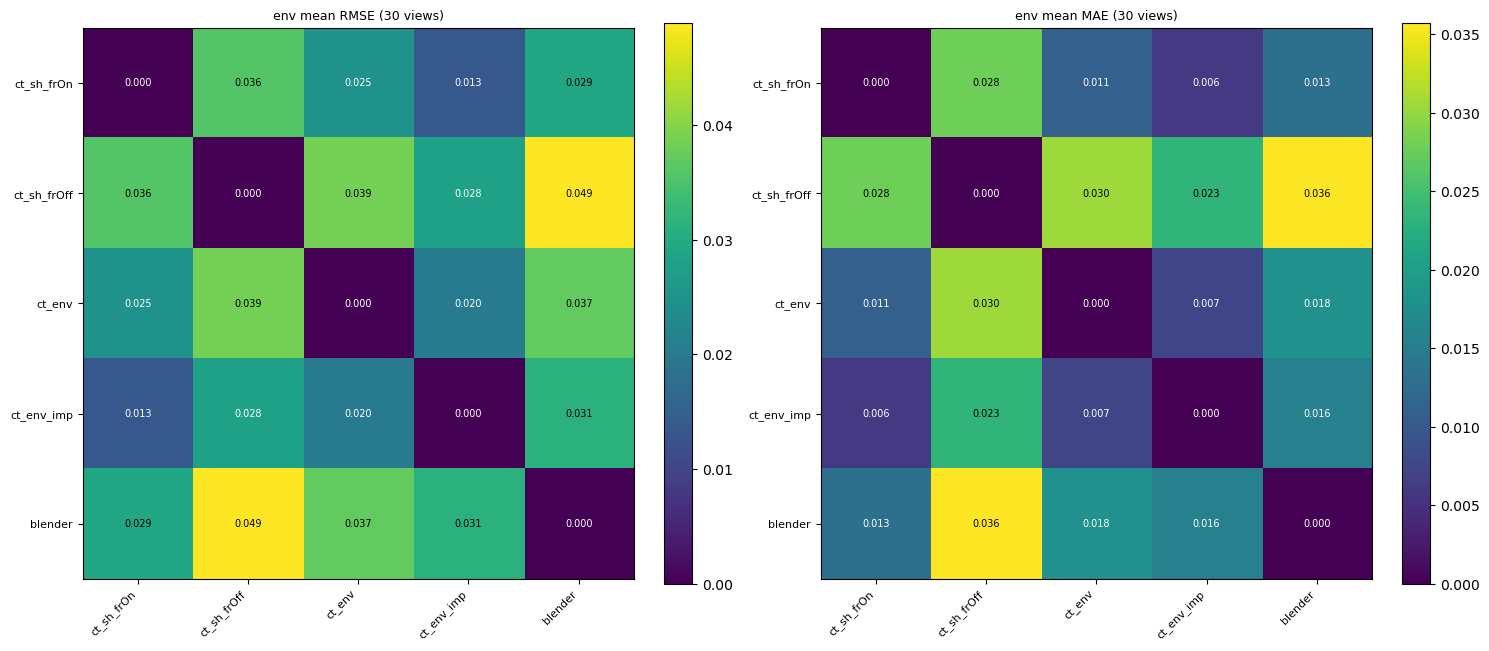


=== env_ground: mean RMSE over 30 view(s) ===
                  ct_sh_frOn  ct_sh_frOff  ct_env  ct_env_imp  blender_noshadow  blender_shadow
ct_sh_frOn            0.0000       0.0824  0.4449      0.0753            0.0777          0.1525
ct_sh_frOff           0.0824       0.0000  0.4120      0.0302            0.0388          0.1497
ct_env                0.4449       0.4120  0.0000      0.4035            0.4074          0.4996
ct_env_imp            0.0753       0.0302  0.4035      0.0000            0.0403          0.1431
blender_noshadow      0.0777       0.0388  0.4074      0.0403            0.0000          0.1266
blender_shadow        0.1525       0.1497  0.4996      0.1431            0.1266          0.0000


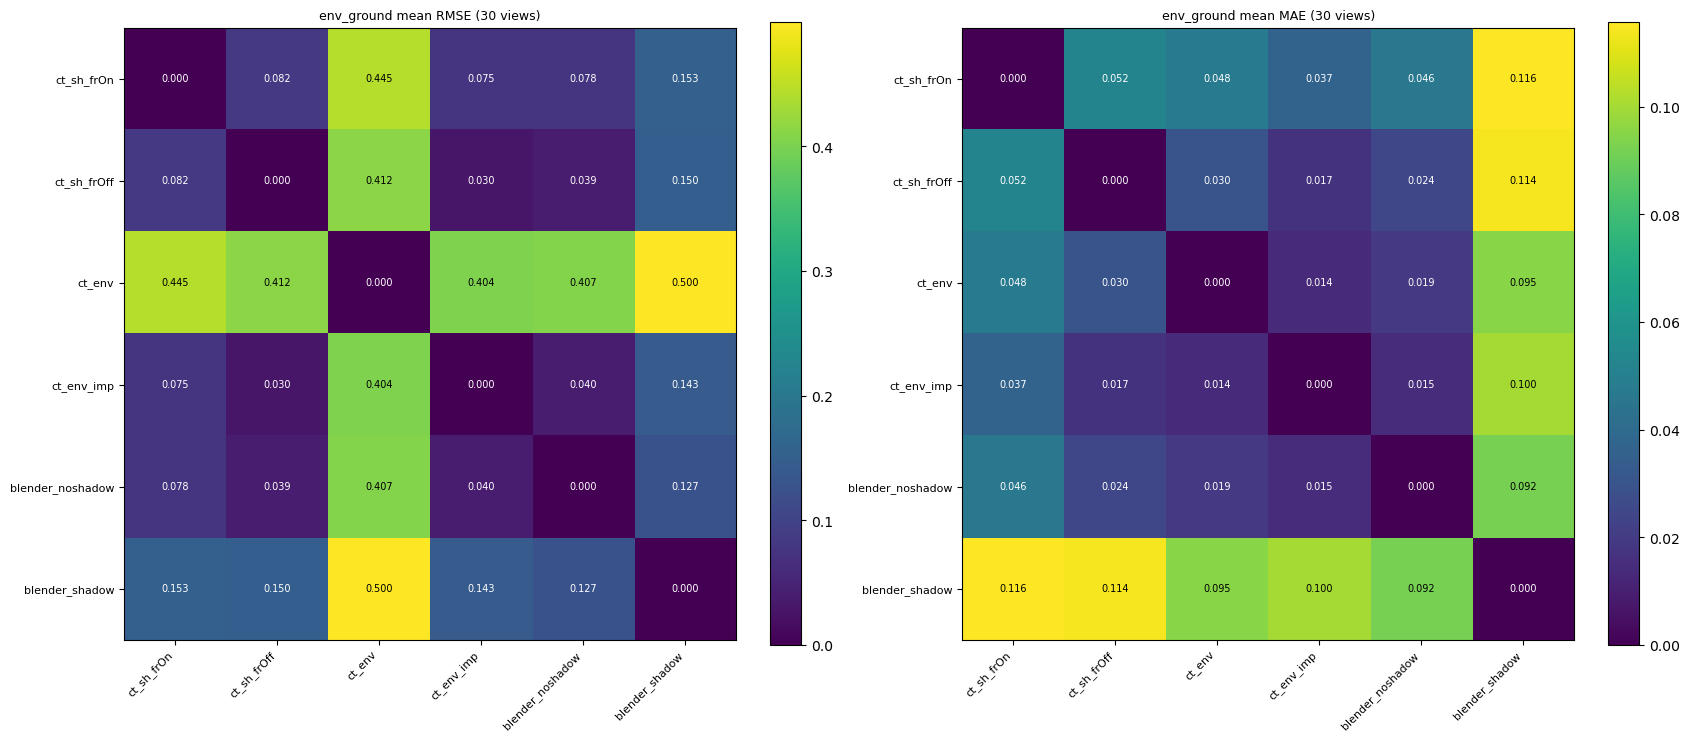

In [6]:
# ── averaged similarity (confusion) matrices over views, separate env / env_ground ──
for cond, labels in CONDS.items():
    if not SIM_ACC[cond]['rmse']:
        continue
    n = len(SIM_ACC[cond]['rmse'])
    avg = {m: np.mean(SIM_ACC[cond][m], axis=0) for m in ('rmse', 'mae')}
    print(f'\n=== {cond}: mean RMSE over {n} view(s) ===')
    print(pd.DataFrame(avg['rmse'], index=labels, columns=labels).round(4).to_string())
    fig, ax = plt.subplots(1, 2, figsize=(2.0 * (1.0 * len(labels) + 2.5), 1.0 * len(labels) + 2))
    for a, m in zip(ax, ('rmse', 'mae')):
        _plot_matrix(a, labels, avg[m], f'{cond} mean {m.upper()} ({n} views)')
        plt.colorbar(a.images[0], ax=a, fraction=0.046)
    plt.tight_layout(); fig.savefig(DS_ROOT / 'compare' / f'AVG_{cond}.png', dpi=90); plt.show()

## B — build datasets (run locally, then upload)

Builds every self-contained dataset dir under `DS_ROOT/datasets/` (all pre-reduced to the ÷DOWNSAMPLE grid, GT SH embedded). This is the only step to run on your machine before uploading — decomposition is a SEPARATE step (Part C below, or `run_decomposition.py` on the VM).

Set `BUILD_VIEWS` at the top of the build cell to prepare a single view (e.g. `'00154c06_v0'`) or a list of views; leave it `None` to build every discovered view.

In [3]:
import shutil
# ── shared: write GT maps (already at target res) as the dataset's GT PNGs ─────
def _write_gt_maps(out_dir, gt):
    '''gt: dict of float maps (normals,mask,albedo,rough,metal) at target res.
    Re-encodes with the zero-normal background preserved so load_scene's mask
    (normals.sum>0) matches. Identical encoding for CT and blender datasets.'''
    def _wpng(a, p, mode16=False):
        a = a.squeeze()
        if mode16:
            Image.fromarray((np.clip(a, 0, 1) * 65535).astype(np.uint16)).save(p)
        elif a.ndim == 2:
            Image.fromarray((np.clip(a, 0, 1) * 255).astype(np.uint8)).save(p)
        else:
            Image.fromarray((np.clip(a[:, :, :3], 0, 1) * 255).astype(np.uint8)).save(p)
    nrm = ((gt['normals'] + 1) / 2 * 255).astype(np.uint8)
    nrm[~gt['mask']] = 0
    Image.fromarray(nrm).save(out_dir / 'normals.png')
    _wpng(gt['albedo'], out_dir / 'albedo.png')
    _wpng(gt['rough'], out_dir / 'roughness.png', mode16=True)
    _wpng(gt['metal'], out_dir / 'metallic.png', mode16=True)
    # lossless float copies (rerender/decomp without 8/16-bit truncation)
    nrm_f = gt['normals'].astype(np.float32).copy(); nrm_f[~gt['mask']] = 0.0
    np.save(out_dir / 'normals.npy', nrm_f)
    np.save(out_dir / 'albedo.npy', gt['albedo'][:, :, :3].astype(np.float32))
    np.save(out_dir / 'roughness.npy', gt['rough'].astype(np.float32))
    np.save(out_dir / 'metallic.npy', gt['metal'].astype(np.float32))

def _stride_gt(gt, ds):
    if ds > 1:
        gt = {k: (np.ascontiguousarray(v[::ds, ::ds]) if isinstance(v, np.ndarray) else v)
              for k, v in gt.items()}
    return gt

def build_ct_dataset(gt_dir, out_dir, sh_list, shader, diffuse_fresnel=True):
    '''Render GT maps under all lights with `shader` at the DOWNSAMPLEd
    resolution; write a self-contained exr-variant dataset dir (decomposed with
    downsample=1). `diffuse_fresnel` chooses the DATA diffuse model:
    True = (1-F)(1-m) (shader default), False = (1-m).'''
    ds = DOWNSAMPLE
    cfg_p = out_dir / 'config.json'
    if (cfg_p.exists() and json.loads(cfg_p.read_text()).get('prereduced_downsample') == ds
            and json.loads(cfg_p.read_text()).get('diffuse_fresnel') == diffuse_fresnel):
        return
    shutil.rmtree(out_dir, ignore_errors=True)
    out_dir.mkdir(parents=True, exist_ok=True)
    gt = _stride_gt(load_gt_view(gt_dir), ds)
    _write_gt_maps(out_dir, gt)
    r = GTRenderer(gt)
    for i, sh in enumerate(sh_list):
        np.save(out_dir / f'light_{i:03d}.npy',
                r.render(sh, shader, diffuse_fresnel=diffuse_fresnel).astype(np.float32))
        np.save(out_dir / f'sh_{i:03d}.npy', np.asarray(sh, np.float32))
    cfg_p.write_text(json.dumps(
        {'variant': 'exr', 'n_lights': len(sh_list), 'light_type': 'light',
         'ct_shader': shader, 'src': str(gt_dir), 'prereduced_downsample': ds,
         'diffuse_fresnel': diffuse_fresnel}, indent=1))

def build_blender_dataset(v, cond, out_dir):
    '''Blender exr images → self-contained exr-variant dataset dir, PRE-REDUCED
    to the DOWNSAMPLEd grid (decomposed with downsample=1) so the whole
    datasets/ folder is small to upload. GT SH scaled by the exr normalisation.'''
    ds = DOWNSAMPLE
    cfg_p = out_dir / 'config.json'
    if cfg_p.exists() and json.loads(cfg_p.read_text()).get('prereduced_downsample') == ds:
        return
    shutil.rmtree(out_dir, ignore_errors=True)
    stem = {'env': 'env', 'env_ground_noshadow': 'env_ground_noshadow',
            'env_ground_shadow': 'env_ground_shadow'}[cond]
    src = v['env_dir'] if cond == 'env' else v['ground_dir']
    build_3dfront_dataset(src, out_dir, variant='exr', lighting=stem)   # full-res intermediate
    cfg = json.loads(cfg_p.read_text())
    exr_scale = float(cfg.get('exr_scale', 1.0) or 1.0)
    sh_list = v['sh_env'] if cond == 'env' else v['sh_ground']
    # trim extras (build_3dfront_dataset globs every on-disk exr; MAX_LIGHTS may cap sh_list)
    for f in sorted(out_dir.glob('light_*.npy'))[len(sh_list):]:
        f.unlink(); f.with_name(f.stem + '_preview.png').unlink(missing_ok=True)
    # stride light npy + re-encode GT to the reduced grid, drop full-res previews
    for f in sorted(out_dir.glob('light_*.npy')):
        if ds > 1:
            np.save(f, np.ascontiguousarray(np.load(f)[::ds, ::ds]))
    for f in out_dir.glob('light_*_preview.png'):
        f.unlink()
    _write_gt_maps(out_dir, _stride_gt(load_gt_view(out_dir), ds))
    for i, sh in enumerate(sh_list):
        np.save(out_dir / f'sh_{i:03d}.npy', (np.asarray(sh, np.float32) / exr_scale))
    cfg['prereduced_downsample'] = ds
    cfg_p.write_text(json.dumps(cfg, indent=1))

# dataset specs: CT re-renders (each shader × both diffuse-Fresnel modes) + blender
def dataset_specs(v):
    specs = []
    _ct_src = {'env': (v['env_dir'], v['sh_env']),
               'env_ground': (v['ground_dir'], v['sh_ground'])}
    for cond in CT_CONDS:
        gt_dir, sh_list = _ct_src[cond]
        for shader in CT_SHADERS:
            for fr in CT_FRESNEL_MODES:
                frtag = 'frOn' if fr else 'frOff'
                specs.append((f'ct-{shader}-{frtag}_{cond}',
                              lambda o, g=gt_dir, s=sh_list, sh=shader, f=fr:
                                  build_ct_dataset(g, o, s, sh, diffuse_fresnel=f)))
    for cond in BLENDER_CONDS:
        specs.append((f'blender_{cond}', lambda o, vv=v, c=cond: build_blender_dataset(vv, c, o)))
    return specs

print(f'{len(dataset_specs(views[0]))} conditions per view:')
for name, _ in dataset_specs(views[0]):
    print('  ', name)

4 conditions per view:
   ct-ct_sh-frOn_env
   ct-ct_sh-frOn_env_ground
   blender_env
   blender_env_ground_shadow


In [6]:
# ── build all datasets (this is the "prepare on my machine" step) ─────────────
# Optionally build only a single view (or a few) instead of every discovered
# view. None = all; else a view key or list of them, e.g. '00154c06_v0'.
BUILD_VIEWS = None          # e.g. '00154c06_v0'  or  ['00154c06_v0', '0003d406_v1']
# BUILD_VIEWS = '1f19c3ef_v2'          

_bwant = ({BUILD_VIEWS} if isinstance(BUILD_VIEWS, str)
          else set(BUILD_VIEWS) if BUILD_VIEWS else None)
_build = [v for v in views if _bwant is None or v['key'] in _bwant]
if _bwant is not None:
    assert _build, f'no discovered view matches {sorted(_bwant)} (have {[v["key"] for v in views]})'
    _missing = _bwant - {v['key'] for v in _build}
    if _missing:
        print(f'WARNING: requested view(s) not discovered: {sorted(_missing)}')
print(f'building {len(_build)} view(s)'
      + (f'  (filtered to {sorted(_bwant)})' if _bwant is not None else '  (all)'))

built = 0
for _vi, v in enumerate(_build):
    specs = dataset_specs(v)
    for ds_name, builder in specs:
        builder(DS_ROOT / 'datasets' / v['key'] / ds_name)
        built += 1
    print(f'[{_vi+1}/{len(_build)}] {v["key"]}: {len(specs)} datasets ready', flush=True)
print(f'\nDONE: {built} dataset dir(s) under {DS_ROOT / "datasets"}')
print('Upload that folder to the VM and run:')
print('  python run_decomposition.py --datasets_root <uploaded>/datasets '
      '--runs_root <out>/runs --sh_orders 2 3 --n_train {} --n_val {}'.format(N_TRAIN, N_VAL))

building 67 view(s)  (all)
[1/67] 1c349305_v0: 4 datasets ready
[2/67] 1c349305_v1: 4 datasets ready
[3/67] 1c349305_v2: 4 datasets ready
[4/67] 1c349305_v3: 4 datasets ready
[5/67] 1c349305_v4: 4 datasets ready
[6/67] 1f19c3ef_v0: 4 datasets ready
[7/67] 1f19c3ef_v1: 4 datasets ready
[8/67] 1f19c3ef_v2: 4 datasets ready
[9/67] 1f19c3ef_v3: 4 datasets ready
[10/67] 1f19c3ef_v4: 4 datasets ready
[11/67] 1f19c3ef_v5: 4 datasets ready
[12/67] 29f1ce41_v0: 4 datasets ready
[13/67] 29f1ce41_v1: 4 datasets ready
[14/67] 29f1ce41_v2: 4 datasets ready
[15/67] 29f1ce41_v3: 4 datasets ready
[16/67] 29f1ce41_v4: 4 datasets ready
[17/67] 3764dfa2_v0: 4 datasets ready
[18/67] 3764dfa2_v1: 4 datasets ready
[19/67] 3764dfa2_v2: 4 datasets ready
[20/67] 3764dfa2_v3: 4 datasets ready
[21/67] 3e038beb_v0: 4 datasets ready
[22/67] 3e038beb_v1: 4 datasets ready
[23/67] 3e038beb_v2: 4 datasets ready
[24/67] 4d94c89f_v0: 4 datasets ready
[25/67] 4d94c89f_v1: 4 datasets ready
[26/67] 4d94c89f_v2: 4 datasets 

## C — decompose (OPTIONAL local run)

For quick local tests only. On the VM, run `run_decomposition.py` on the uploaded `datasets/` folder instead (resumable, wandb logging). Skip this cell if you're decomposing on the VM.

Set `DECOMP_VIEWS` at the top of the cell to decompose a single view (e.g. `'00154c06_v0'`) or a list of views; leave it `None` to run the whole `datasets/` tree.

In [4]:
# ── intrinsics + relighting plots from a finished run dir ──────────────────────
def save_intrinsics_plot(run_dir, m, save_path):
    gt = Path(m['scene'])
    panels = [('albedo GT', gt / 'albedo.png', None),
              ('albedo est', run_dir / 'albedo_scaled.png', None),
              ('albedo err', run_dir / 'albedo_err.npy', f"RMSE={m['albedo_rmse']:.3f}"),
              ('rough GT', gt / 'roughness.png', None),
              ('rough est', run_dir / 'roughness_est.png', None),
              ('rough err', run_dir / 'roughness_err.npy', f"MAE={m['roughness_err_mean']:.3f}"),
              ('metal GT', gt / 'metallic.png', None),
              ('metal est', run_dir / 'metallic_est.png', None),
              ('metal err', run_dir / 'metallic_err.npy', f"MAE={m['metallic_err_mean']:.3f}")]
    fig, ax = plt.subplots(3, 3, figsize=(9.5, 9.5))
    for a, (t, p, sub) in zip(ax.flat, panels):
        if Path(p).exists():
            im = np.load(p) if str(p).endswith('.npy') else np.array(Image.open(p))
            if str(p).endswith('.npy'):
                im = im.squeeze()
                if im.ndim == 3 and im.shape[-1] == 3:
                    im = im.mean(-1)
            a.imshow(im, cmap='gray' if im.ndim == 2 else None)
        a.set_title(t + (f'\n{sub}' if sub else ''), fontsize=8); a.axis('off')
    fig.suptitle(run_dir.name[:70], fontsize=8); plt.tight_layout()
    fig.savefig(save_path, dpi=80); plt.close(fig)

def save_relight_plots(run_dir, m, ds_dir, downsample):
    '''One target/relit/residual panel per val light (saved to run_dir/relight/plots).'''
    keys = m.get('relight_keys', [])
    rmses, maes = m.get('relight_rmse_per_light', []), m.get('relight_mae_per_light', [])
    pdir = run_dir / 'relight' / 'plots'; pdir.mkdir(parents=True, exist_ok=True)
    for k, key in enumerate(keys):
        relit_p = run_dir / 'relight' / f'relit_{key}.npy'
        tgt_p = ds_dir / f'{key}.npy'
        if not relit_p.exists() or not tgt_p.exists():
            continue
        relit = np.load(relit_p)
        tgt = np.load(tgt_p)[::downsample, ::downsample]
        resid = np.abs(relit - tgt).mean(-1)
        fig, ax = plt.subplots(1, 3, figsize=(10, 3.4))
        ax[0].imshow(np.clip(tgt / 2, 0, 1)); ax[0].set_title(f'target {key}', fontsize=8)
        ax[1].imshow(np.clip(relit / 2, 0, 1)); ax[1].set_title('relit (est intrinsics + GT light)', fontsize=8)
        im = ax[2].imshow(resid, cmap='inferno')
        rm = rmses[k] if k < len(rmses) else float('nan'); ma = maes[k] if k < len(maes) else float('nan')
        ax[2].set_title(f'residual  RMSE={rm:.4f}  MAE={ma:.4f}', fontsize=8)
        plt.colorbar(im, ax=ax[2], fraction=0.046)
        for a in ax: a.axis('off')
        plt.tight_layout(); fig.savefig(pdir / f'relight_{key}.png', dpi=80); plt.close(fig)

In [ ]:
# ── Part C (OPTIONAL, local): decompose the built datasets. On the VM use
# run_decomposition.py instead — it consumes the same DS_ROOT/datasets folder. ──
# Optionally restrict to a single view (or a few) instead of the whole datasets/
# tree. None = all views; else a view key or list of them, e.g. '00154c06_v0'.
DECOMP_VIEWS = None          # e.g. '00154c06_v0'  or  ['00154c06_v0', '0003d406_v1']

DECOMP_ROWS = []
_ds_root = DS_ROOT / 'datasets'
_want = ({DECOMP_VIEWS} if isinstance(DECOMP_VIEWS, str)
         else set(DECOMP_VIEWS) if DECOMP_VIEWS else None)
_items = sorted((vd.name, dd) for vd in _ds_root.iterdir()
                if vd.is_dir() and (_want is None or vd.name in _want)
                for dd in sorted(vd.iterdir()) if dd.is_dir() and (dd / 'config.json').exists())
if _want is not None:
    _missing = _want - {v for v, _ in _items}
    assert _items, f'no datasets for view(s) {sorted(_want)} under {_ds_root}'
    if _missing:
        print(f'WARNING: requested view(s) not found: {sorted(_missing)}')
print(f'decomposing {len({v for v,_ in _items})} view(s), {len(_items)} dataset(s)'
      + (f'  (filtered to {sorted(_want)})' if _want is not None else '  (all)'))
for view_key, ds_dir in _items:
    ds_name = ds_dir.name
    _dcfg = json.loads((ds_dir / 'config.json').read_text())
    eff_ds = 1 if _dcfg.get('prereduced_downsample', 0) > 1 else DOWNSAMPLE
    for order in SH_ORDERS:
        for shader in DECOMP_SHADERS:
            cfg = dict(DECOMP_BASE_CFG)
            cfg.update(shader={'ct_sh': 'ct_sh', 'ct_env': 'ct_env', 'ct_env_imp': 'ct_env'}[shader],
                       sh_order=order, downsample=eff_ds,
                       n_images=N_TRAIN + N_VAL, val_images=N_VAL)
            if shader == 'ct_env_imp':
                cfg['spec_importance'] = True; cfg['spec_samples'] = SPEC_SAMPLES
            tag = f'{view_key}__{ds_name}__{shader}_SH{order}_ds{DOWNSAMPLE}_N{N_TRAIN}'
            out_dir = DS_ROOT / 'runs' / tag
            if (out_dir / 'metrics.json').exists() and not FORCE_DECOMPOSE:
                m = json.loads((out_dir / 'metrics.json').read_text()); print(f'{tag}: cached')
            else:
                m = decompose_scene(ds_dir, out_dir, cfg_overrides=cfg, device=DEVICE,
                                    wandb_project=WANDB_PROJECT_B)
                save_intrinsics_plot(out_dir, m, out_dir / 'intrinsics.png')
                save_relight_plots(out_dir, m, ds_dir, eff_ds)
                (out_dir / 'report.json').write_text(json.dumps({
                    'view': view_key, 'dataset': ds_name, 'decomp_shader': shader, 'sh_order': order,
                    'albedo_rmse': m['albedo_rmse'], 'albedo_mae': m.get('albedo_mae'),
                    'roughness_mae': m['roughness_err_mean'], 'metallic_mae': m['metallic_err_mean'],
                    'train_recon_rmse': m['recon_rmse'], 'train_recon_mae': m.get('recon_mae'),
                    'val_relight_rmse': m.get('relight_rmse'), 'val_relight_mae': m.get('relight_mae'),
                    'final_loss': m['final_loss'], 'n_train': m.get('n_train_images'),
                    'n_val': m.get('n_val_images')}, indent=1))
            DECOMP_ROWS.append(dict(
                view=view_key, dataset=ds_name, shader=shader, sh_order=order,
                albedo_rmse=m['albedo_rmse'], albedo_mae=m.get('albedo_mae'),
                roughness_mae=m['roughness_err_mean'], metallic_mae=m['metallic_err_mean'],
                train_recon_rmse=m['recon_rmse'], val_relight_rmse=m.get('relight_rmse'),
                val_relight_mae=m.get('relight_mae'), final_loss=m['final_loss']))

df_dec = pd.DataFrame(DECOMP_ROWS)
if len(df_dec):
    df_dec.to_csv(DS_ROOT / 'decomposition_summary.csv', index=False)
    print('\n', df_dec.groupby(['dataset', 'sh_order'])[
        ['albedo_rmse', 'roughness_mae', 'metallic_mae', 'train_recon_rmse', 'val_relight_rmse']
    ].mean().round(4).to_string())

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\felix\_netrc.


  [val] holding out last 28 images for relighting (100 train images)


wandb: Currently logged in as: flaarmann (adlr-latents) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  [init]          loss=1.419e-01  data=1.416e-01  metallic=0.500  roughness=0.100
  [   0]    1.2s  loss=4.997e-04  data=1.747e-04  metallic=0.501  roughness=0.100


KeyboardInterrupt: 

wandb: WARNING Tried to log to step -1 that is less than the current step 0. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


## Sanity checks — init-from-GT (one scene, SH2)

Three inverse-crime consistency checks on a single `ct_sh`-rendered view (Fresnel-ON
data + always-Fresnel-ON optimizer), with the regularizers switched off:

1. **`init_gt`** — initialise albedo / lighting / metallic / roughness at GT and
   decompose *everything*. The optimizer starts at the true solution, so it should
   barely move.
2. **`init_gt_frozen`** — same GT init but **freeze intrinsics** (`opt_params={'sh'}`),
   so only the per-image lighting is optimized.
3. **`init_gt_frozen_all`** — freeze **everything** (`opt_params=[]`, `n_iter=1`): a
   pure forward evaluation of the model at GT intrinsics *and* GT lighting, with no
   fitting at all.

Check 3 is the reference: `recon_rmse` and `relight_rmse` must come out **equal**,
because both then measure the same thing — the forward-model/data mismatch. That
mismatch is not zero: the images were rendered from *float* GT maps while the
dataset stores (truncated) 8-bit `albedo.png` / `normals.png`, which is what the
decomposer loads. So it sets the floor for every metric.

In checks 1–2 `relight_rmse > recon_rmse`. That gap is **not** train-vs-val — it is
fitted-vs-fixed lighting. `recon` is measured where the per-image SH was optimized,
so the 9x3 free coefficients soak up the systematic part of the mismatch (truncation
biases albedo *down*, so the model renders dark and lighting just brightens);
`relight` uses GT SH untouched and sees the whole thing.


sanity scene: 00004f89_v0/ct-ct_sh-frOn_env   SH2  downsample=1

-- init_gt_frozen_all: {'init_from_gt': True, 'freeze_intrinsics': True, 'opt_params': []} {'n_iter': 1, 'log_every': 1} --


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\felix\_netrc.


  [val] holding out last 28 images for relighting (100 train images)


wandb: Currently logged in as: flaarmann (adlr-latents) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  [init]          loss=5.470e-06  data=5.470e-06  metallic=0.005  roughness=0.337
  [   0]    0.1s  loss=5.470e-06  data=5.470e-06  metallic=0.005  roughness=0.337


albedo_mae,▁
albedo_rmse,▁
elapsed_s,▁█
final_loss,▁
loss/albedo_scale_b,▁
loss/albedo_scale_g,▁
loss/albedo_scale_mean,▁
loss/albedo_scale_r,▁
loss/data,▁
loss/metallic_binarize,▁
+19,...


  0.2s  albedo RMSE=0.0000  metallic=0.005(GT=0.005)  roughness=0.337(GT=0.337)  -> results\3dfront-batch\sanity\00004f89_v0__ct-ct_sh-frOn_env__SH2__init_gt_frozen_all


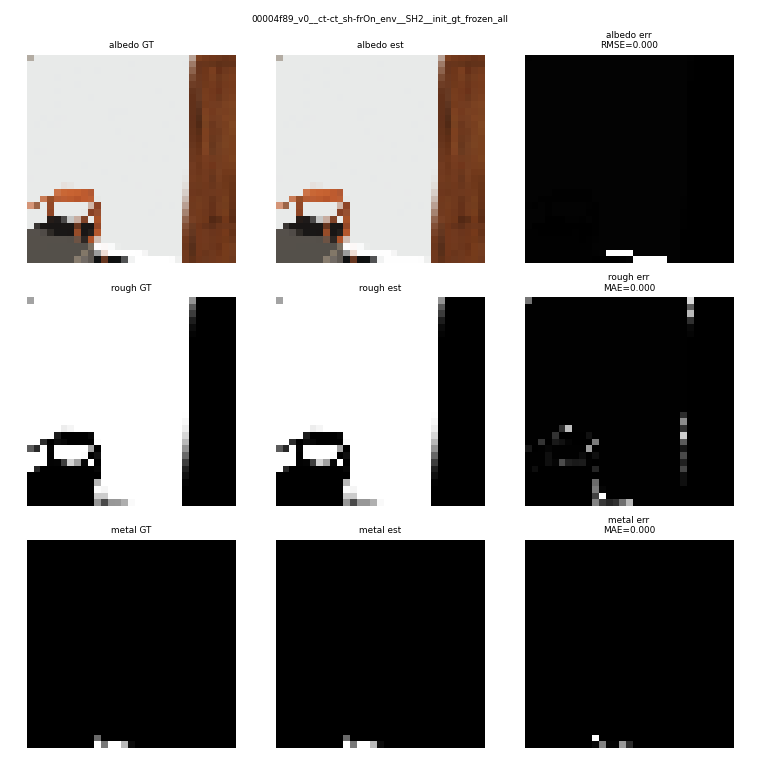


              check  albedo_rmse  roughness_mae  metallic_mae  train_recon_rmse  val_relight_rmse  final_loss  relight/recon
init_gt_frozen_all          0.0            0.0           0.0           0.00208           0.00212     0.00001        1.02306

expected: frozen_all -> recon ~= relight (pure model/data mismatch, no fitting);
          the other two -> relight > recon, the gap = what the free SH absorbs.


In [ ]:
# -- Sanity checks: one ct_sh scene, SH2, init-from-GT (frozen intrinsics / +SH) --
from IPython.display import display

SANITY_DATASET = 'ct-ct_sh-frOn_env'   # ct_sh-rendered, Fresnel-ON, plain env
SANITY_ORDER   = 2

_ds_root = DS_ROOT / 'datasets'
_hit = next(((vd.name, vd / SANITY_DATASET)
             for vd in sorted(_ds_root.iterdir()) if vd.is_dir()
             and (vd / SANITY_DATASET / 'config.json').exists()), None)
assert _hit, f'no view has {SANITY_DATASET} under {_ds_root} -- build datasets first (Part B)'
_sview, _sds = _hit
_scfg  = json.loads((_sds / 'config.json').read_text())
_effds = 1 if _scfg.get('prereduced_downsample', 0) > 1 else DOWNSAMPLE
print(f'sanity scene: {_sview}/{SANITY_DATASET}   SH{SANITY_ORDER}  downsample={_effds}')

# (label, decompose flags, per-check cfg overrides)
#   init_gt            : everything starts at GT, everything is optimized
#   init_gt_frozen     : intrinsics pinned at GT, per-image SH still optimized
#   init_gt_frozen_all : NOTHING is optimized (opt_params=[]) -> a pure forward
#       evaluation of the model at GT intrinsics + GT lighting. n_iter=1 suffices.
#       Here recon and relight must AGREE: both just measure the forward-model /
#       data mismatch (the 8-bit albedo/normals GT vs the float maps the images
#       were rendered from). Any gap in the two checks above is exactly what the
#       free per-image SH is able to absorb.
SANITY_CHECKS = [
    ('init_gt',            dict(init_from_gt=True, freeze_intrinsics=False), {}),
    # ('init_gt_frozen',     dict(init_from_gt=True, freeze_intrinsics=True),  {}),
    # ('init_gt_frozen_all', dict(init_from_gt=True, freeze_intrinsics=True, opt_params=[]),
    #                       dict(n_iter=1, log_every=1)),
]
_srows = []
for _label, _flags, _extra in SANITY_CHECKS:
    _cfg = dict(DECOMP_BASE_CFG)
    _cfg.update(shader='ct_sh', sh_order=SANITY_ORDER, downsample=_effds,
                lambda_tv=0, lambda_metallic_binarize=0,
                n_images=N_TRAIN + N_VAL, val_images=N_VAL, **_flags)
    _cfg.update(_extra)
    _out = DS_ROOT / 'sanity' / f'{_sview}__{SANITY_DATASET}__SH{SANITY_ORDER}__{_label}'
    print(f'\n-- {_label}: {_flags} {_extra} --')
    _m = decompose_scene(_sds, _out, cfg_overrides=_cfg, device=DEVICE,
                         wandb_project=WANDB_PROJECT_B)
    save_intrinsics_plot(_out, _m, _out / 'intrinsics.png')
    _srows.append(dict(check=_label,
        albedo_rmse=_m['albedo_rmse'], roughness_mae=_m['roughness_err_mean'],
        metallic_mae=_m['metallic_err_mean'], train_recon_rmse=_m['recon_rmse'],
        val_relight_rmse=_m.get('relight_rmse'), final_loss=_m['final_loss']))
    display(Image.open(_out / 'intrinsics.png'))

_sdf = pd.DataFrame(_srows)
_sdf['relight/recon'] = _sdf['val_relight_rmse'] / _sdf['train_recon_rmse']
print('\n', _sdf.round(5).to_string(index=False))
print('\nexpected: frozen_all -> recon ~= relight (pure model/data mismatch, no fitting);'
      '\n          the other two -> relight > recon, the gap = what the free SH absorbs.')


## Final: metrics across views (mean ± std)

In [6]:
if len(df_dec):
    metrics = ['albedo_rmse', 'albedo_mae', 'roughness_mae', 'metallic_mae',
               'train_recon_rmse', 'val_relight_rmse', 'val_relight_mae']
    g = df_dec.groupby(['dataset', 'sh_order'])
    mean, std = g[metrics].mean(), g[metrics].std()
    labels = [f'{d}\nSH{o}' for d, o in mean.index]
    fig, axes = plt.subplots(len(metrics), 1, figsize=(max(10, len(labels) * 0.5), 3 * len(metrics)))
    x = np.arange(len(labels))
    for ax, met in zip(axes, metrics):
        ax.bar(x, mean[met].values, yerr=std[met].fillna(0).values, capsize=2)
        ax.set_ylabel(met, fontsize=9); ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=90, fontsize=6)
        ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

    print('\nfull mean±std table:')
    combo = mean.round(4).astype(str) + ' ± ' + std.fillna(0).round(4).astype(str)
    print(combo.to_string())

NameError: name 'df_dec' is not defined

## VM results: mean ± std per rendering source (env / env_ground)

Reads the `runs/` folder produced by `run_decomposition.py` on the VM (mount it and
point `RUNS_ROOT` at it). Accepts either the `decomposition_summary.csv` it writes,
or the per-run `report.json` files as a fallback.

One figure per lighting condition (`env`, `env_ground`), each with three panels:
reconstruction RMSE (train), relighting RMSE (held-out val), and the three
intrinsics MAEs as grouped columns. Bars are the mean over views, error bars the
std across views.

Labels read **`<how it was rendered>` (`<how it was decomposed>`)** — e.g.
`blender (SH2)` = images rendered in Blender, decomposed with CT-SH2;
`ct_sh-frOn (SH3)` = images re-rendered with CT `shade_ct_sh` Fresnel-ON,
decomposed with CT-SH3 (an inverse crime for SH2).


900 run(s) from X:\dlvc\runs



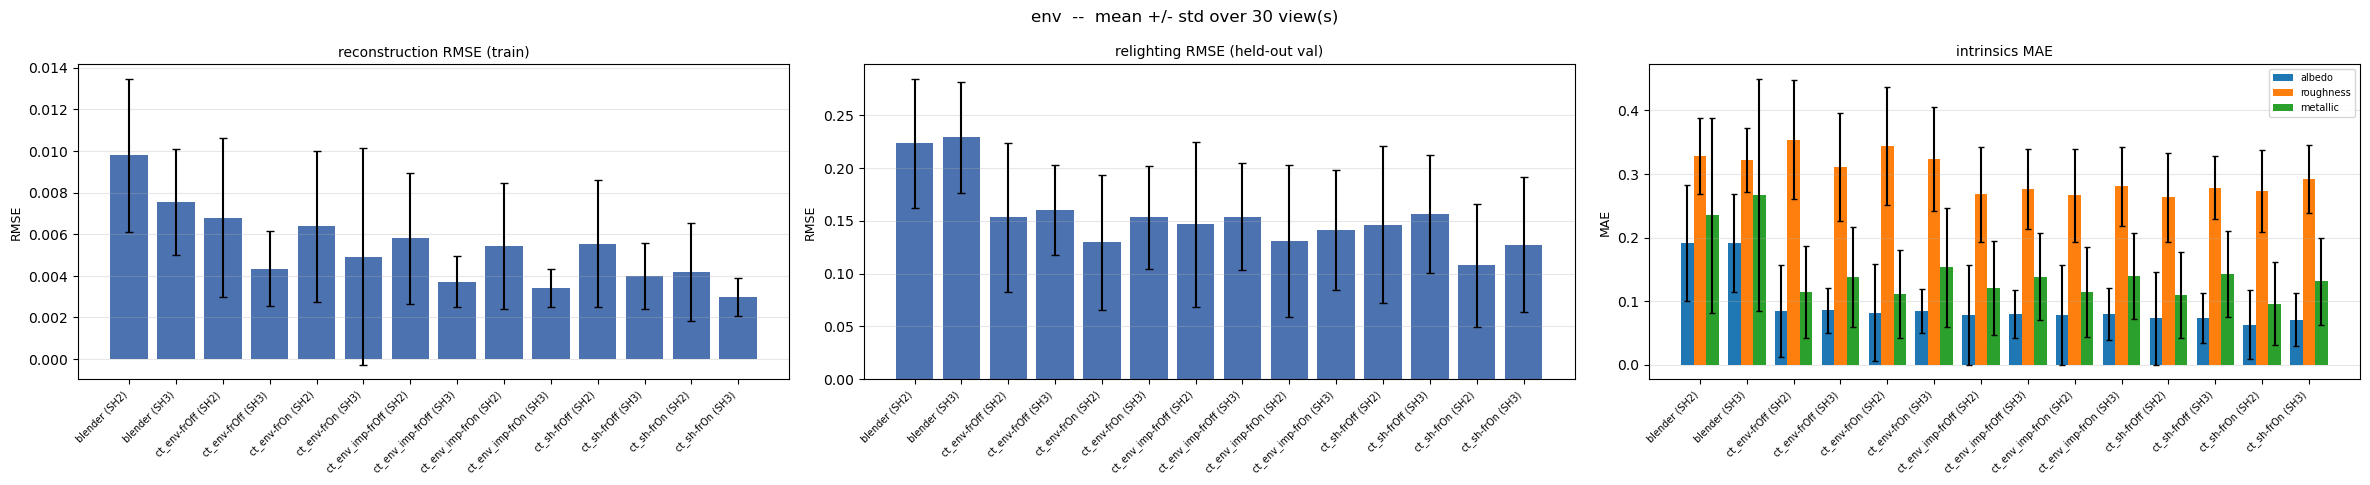

[env]  n_views per label: {'blender (SH2)': np.int64(30), 'blender (SH3)': np.int64(30), 'ct_env-frOff (SH2)': np.int64(30), 'ct_env-frOff (SH3)': np.int64(30), 'ct_env-frOn (SH2)': np.int64(30), 'ct_env-frOn (SH3)': np.int64(30), 'ct_env_imp-frOff (SH2)': np.int64(30), 'ct_env_imp-frOff (SH3)': np.int64(30), 'ct_env_imp-frOn (SH2)': np.int64(30), 'ct_env_imp-frOn (SH3)': np.int64(30), 'ct_sh-frOff (SH2)': np.int64(30), 'ct_sh-frOff (SH3)': np.int64(30), 'ct_sh-frOn (SH2)': np.int64(30), 'ct_sh-frOn (SH3)': np.int64(30)}
                         train_recon_rmse   val_relight_rmse         albedo_mae      roughness_mae       metallic_mae
label                                                                                                                
blender (SH2)           0.0098 +/- 0.0037  0.2232 +/- 0.0607  0.1921 +/- 0.0912  0.3289 +/- 0.0599  0.2349 +/- 0.1535
blender (SH3)           0.0076 +/- 0.0025  0.2292 +/- 0.0525    0.191 +/- 0.077     0.322 +/- 0.05  0.2672 +/- 0.1826
c

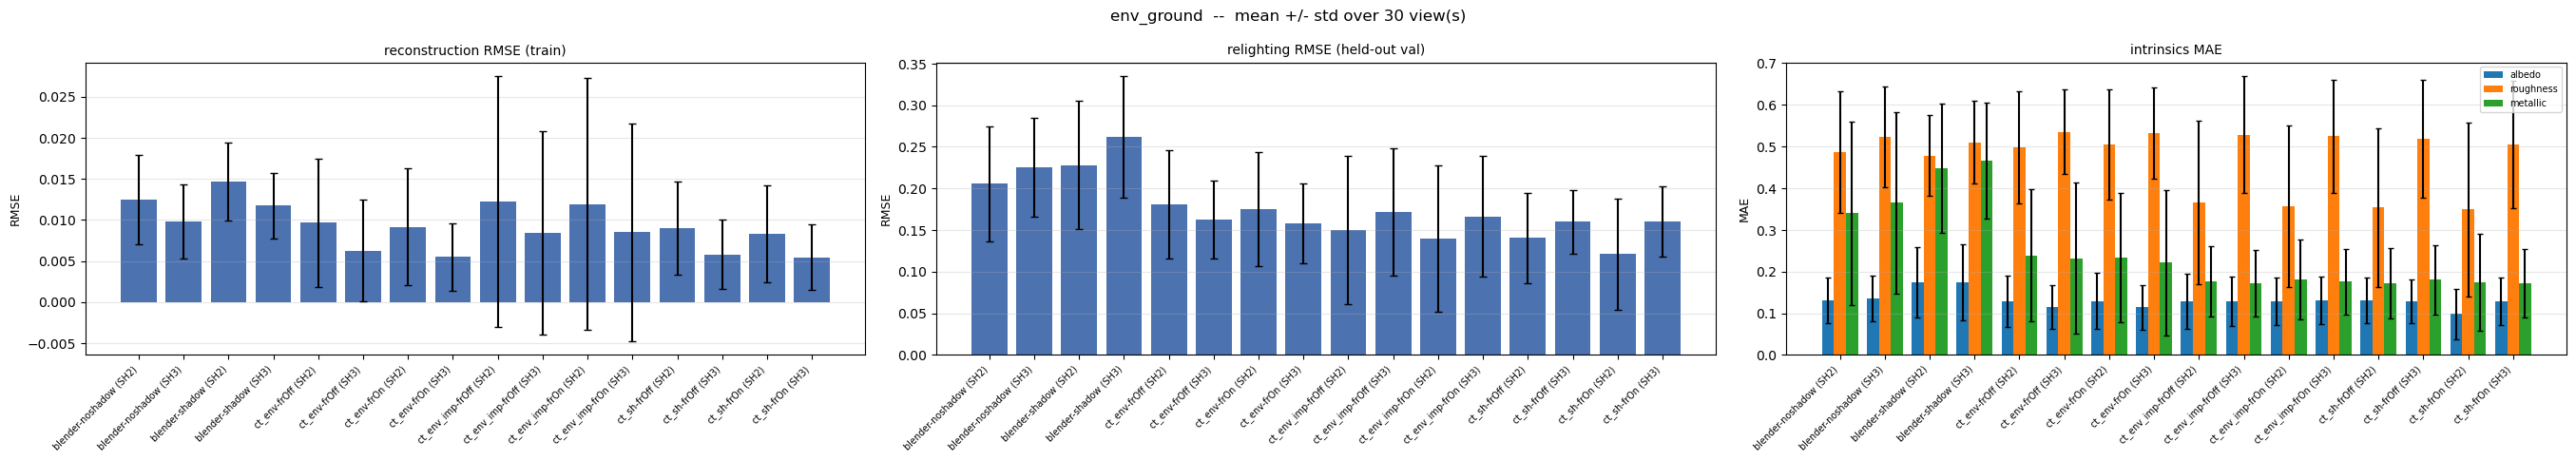

[env_ground]  n_views per label: {'blender-noshadow (SH2)': np.int64(30), 'blender-noshadow (SH3)': np.int64(30), 'blender-shadow (SH2)': np.int64(30), 'blender-shadow (SH3)': np.int64(30), 'ct_env-frOff (SH2)': np.int64(30), 'ct_env-frOff (SH3)': np.int64(30), 'ct_env-frOn (SH2)': np.int64(30), 'ct_env-frOn (SH3)': np.int64(30), 'ct_env_imp-frOff (SH2)': np.int64(30), 'ct_env_imp-frOff (SH3)': np.int64(30), 'ct_env_imp-frOn (SH2)': np.int64(30), 'ct_env_imp-frOn (SH3)': np.int64(30), 'ct_sh-frOff (SH2)': np.int64(30), 'ct_sh-frOff (SH3)': np.int64(30), 'ct_sh-frOn (SH2)': np.int64(30), 'ct_sh-frOn (SH3)': np.int64(30)}
                         train_recon_rmse   val_relight_rmse         albedo_mae      roughness_mae       metallic_mae
label                                                                                                                
blender-noshadow (SH2)  0.0125 +/- 0.0055  0.2054 +/- 0.0693  0.1302 +/- 0.0546  0.4869 +/- 0.1457  0.3396 +/- 0.2209
blender-noshadow (

In [5]:
# -- VM results: recon / relight / intrinsics-MAE, split by env vs env_ground ---
RUNS_ROOT = r'X:\dlvc\runs'        # <-- point at the mounted runs folder

INTRINSIC_MAES = ['albedo_mae', 'roughness_mae', 'metallic_mae']


def load_runs(runs_root):
    """Summary CSV if present, else aggregate the per-run report.json files."""
    runs_root = Path(runs_root)
    csv = runs_root / 'decomposition_summary.csv'
    if csv.exists():
        df = pd.read_csv(csv)
    else:
        rows = [json.loads(p.read_text()) for p in sorted(runs_root.glob('*/report.json'))]
        if not rows:
            raise FileNotFoundError(
                f'no decomposition_summary.csv and no */report.json under {runs_root}')
        df = pd.DataFrame(rows)
    if 'shader' not in df and 'decomp_shader' in df:
        df['shader'] = df['decomp_shader']
    if 'status' in df:                       # drop failed runs
        df = df[df['status'].isin(['ok', 'cached'])]
    return df.copy()


def render_source(ds):
    """dataset dir name -> how the IMAGES were rendered (not how they were decomposed)."""
    if ds.startswith('blender_'):
        rest = ds[len('blender_'):]
        if rest.endswith('_noshadow'):
            return 'blender-noshadow'
        if rest.endswith('_shadow'):
            return 'blender-shadow'
        return 'blender'
    if ds.startswith('ct-'):
        shader, _, tail = ds[len('ct-'):].partition('-')      # 'ct_sh', 'frOn_env_ground'
        fres = 'frOn' if tail.startswith('frOn') else ('frOff' if tail.startswith('frOff') else '')
        return f'{shader}-{fres}' if fres else shader
    return ds


def condition_of(ds):
    return 'env_ground' if 'env_ground' in ds else 'env'


def plot_condition(dfc, cond):
    g = dfc.groupby('label')
    mean, std, n = g.mean(numeric_only=True), g.std(numeric_only=True).fillna(0.0), g.size()
    order = sorted(mean.index)
    mean, std = mean.loc[order], std.loc[order]
    x = np.arange(len(order))

    fig, axes = plt.subplots(1, 3, figsize=(max(13, len(order) * 1.7), 4.9))
    for ax, met, title in ((axes[0], 'train_recon_rmse', 'reconstruction RMSE (train)'),
                           (axes[1], 'val_relight_rmse', 'relighting RMSE (held-out val)')):
        if met not in mean:
            ax.set_visible(False); continue
        ax.bar(x, mean[met].values, yerr=std[met].values, capsize=3, color='#4C72B0')
        ax.set_title(title, fontsize=10); ax.set_ylabel('RMSE', fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(order, rotation=45, ha='right', fontsize=7)
        ax.grid(axis='y', alpha=0.3)

    ax = axes[2]
    mets = [m for m in INTRINSIC_MAES if m in mean]
    w = 0.8 / max(len(mets), 1)
    for i, met in enumerate(mets):
        ax.bar(x + (i - (len(mets) - 1) / 2) * w, mean[met].values, w,
               yerr=std[met].values, capsize=2, label=met.replace('_mae', ''))
    ax.set_title('intrinsics MAE', fontsize=10); ax.set_ylabel('MAE', fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(order, rotation=45, ha='right', fontsize=7)
    ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

    nv = f'{n.min()}' if n.min() == n.max() else f'{n.min()}-{n.max()}'
    fig.suptitle(f'{cond}  --  mean +/- std over {nv} view(s)', fontsize=12)
    plt.tight_layout(); plt.show()

    show = [m for m in ['train_recon_rmse', 'val_relight_rmse', *INTRINSIC_MAES] if m in mean]
    tbl = mean[show].round(4).astype(str) + ' +/- ' + std[show].round(4).astype(str)
    print(f'[{cond}]  n_views per label: {dict(n)}')
    print(tbl.to_string(), '\n')


df_runs = load_runs(RUNS_ROOT)
df_runs['condition'] = df_runs['dataset'].map(condition_of)
_multi_shader = df_runs['shader'].nunique() > 1
df_runs['label'] = [
    f"{render_source(d)} ({s + ' ' if _multi_shader else ''}SH{o})"
    for d, s, o in zip(df_runs['dataset'], df_runs['shader'], df_runs['sh_order'])
]
print(f'{len(df_runs)} run(s) from {RUNS_ROOT}\n')

for _cond in ['env', 'env_ground']:
    _dfc = df_runs[df_runs['condition'] == _cond]
    if len(_dfc):
        plot_condition(_dfc, _cond)
    else:
        print(f'no runs for condition {_cond}')


## Correlations: does fitting the images predict recovering the intrinsics?

Across individual runs (one point = one view x dataset x sh_order), correlate:

* `train_recon_rmse` <-> `val_relight_rmse`
* each intrinsics MAE (albedo / roughness / metallic) <-> `train_recon_rmse`
* each intrinsics MAE <-> `val_relight_rmse`

Reported as Pearson *r* (linear) and Spearman *rho* (monotonic, robust to the
heavy-tailed inverse-crime points), with n and p-values. Run the results cell
above first — this reuses its `df_runs`.

Read it as: a **high recon<->relight** correlation means train fit predicts held-out
lighting generalization. **Low intrinsics-MAE <-> recon** correlation is the
interesting failure mode — it means you can drive the reconstruction to zero while
the albedo/roughness/metallic stay wrong (the model is fitting the images by
trading error between intrinsics and lighting, i.e. the decomposition is
unidentifiable). Correlations are also reported per condition and, in the last
table, *within* each label (pooled across views) so that the between-dataset
spread doesn't manufacture the correlation on its own.


=== ALL runs  (n_runs=900) ===
                                           n  pearson_r  p_pearson  spearman_rho  p_spearman
pair                                                                                        
train_recon_rmse  <->  val_relight_rmse  900     0.4228        0.0        0.3579         0.0
albedo_mae  <->  train_recon_rmse        900     0.4483        0.0        0.5267         0.0
roughness_mae  <->  train_recon_rmse     900     0.2422        0.0        0.1887         0.0
metallic_mae  <->  train_recon_rmse      900     0.2930        0.0        0.4179         0.0
albedo_mae  <->  val_relight_rmse        900     0.6375        0.0        0.6079         0.0
roughness_mae  <->  val_relight_rmse     900     0.3783        0.0        0.4039         0.0
metallic_mae  <->  val_relight_rmse      900     0.4850        0.0        0.4009         0.0 



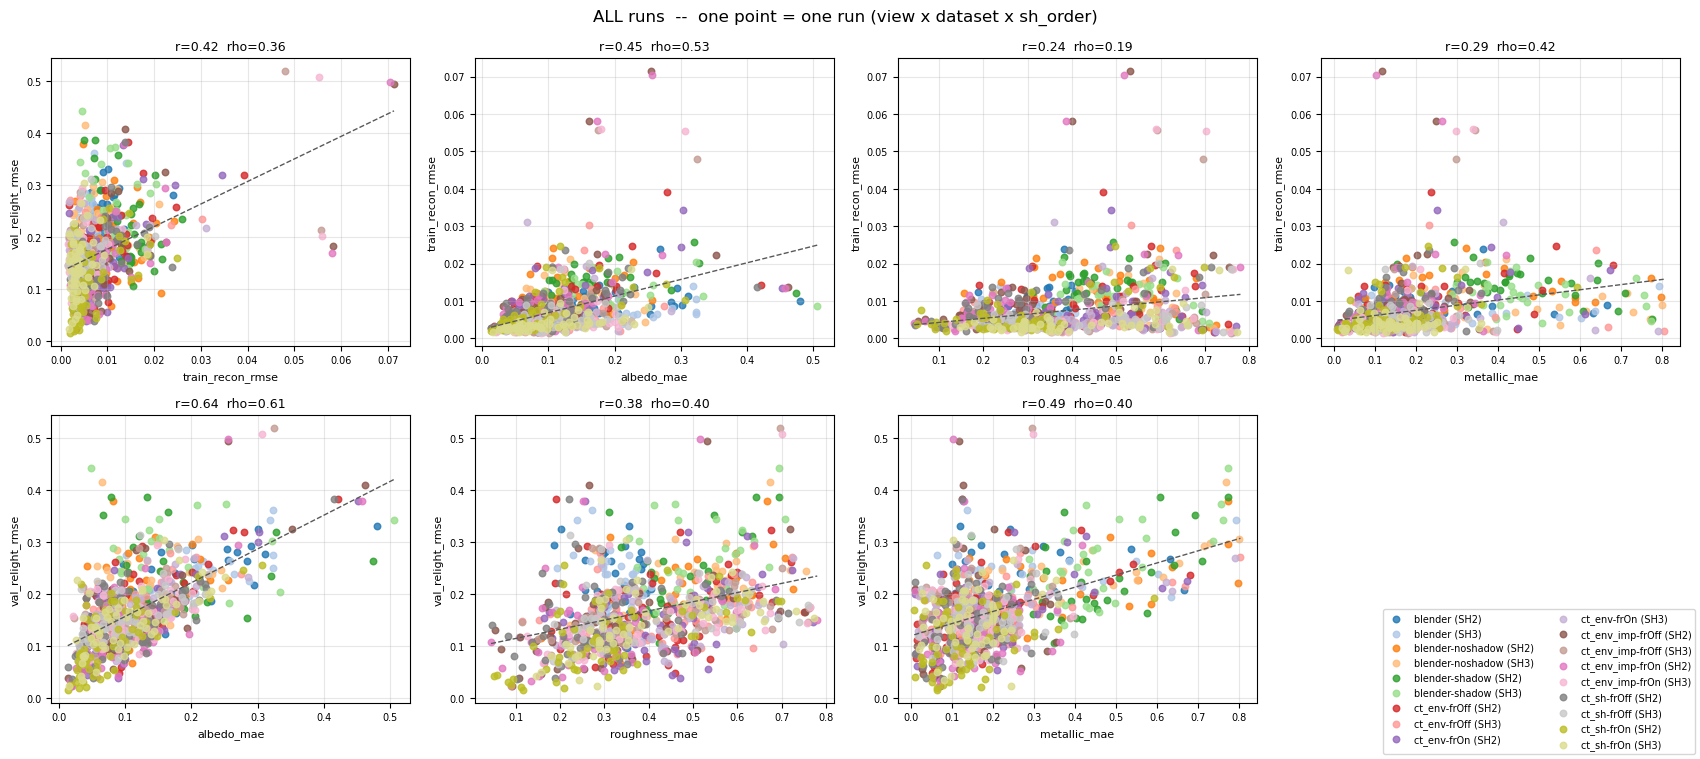

=== condition = env  (n_runs=420) ===
                                           n  pearson_r  p_pearson  spearman_rho  p_spearman
pair                                                                                        
train_recon_rmse  <->  val_relight_rmse  420     0.4258     0.0000        0.3410      0.0000
albedo_mae  <->  train_recon_rmse        420     0.4651     0.0000        0.4095      0.0000
roughness_mae  <->  train_recon_rmse     420    -0.0258     0.5983       -0.1259      0.0098
metallic_mae  <->  train_recon_rmse      420     0.3172     0.0000        0.3394      0.0000
albedo_mae  <->  val_relight_rmse        420     0.7612     0.0000        0.6906      0.0000
roughness_mae  <->  val_relight_rmse     420     0.0508     0.2992        0.1089      0.0257
metallic_mae  <->  val_relight_rmse      420     0.3014     0.0000        0.2256      0.0000 



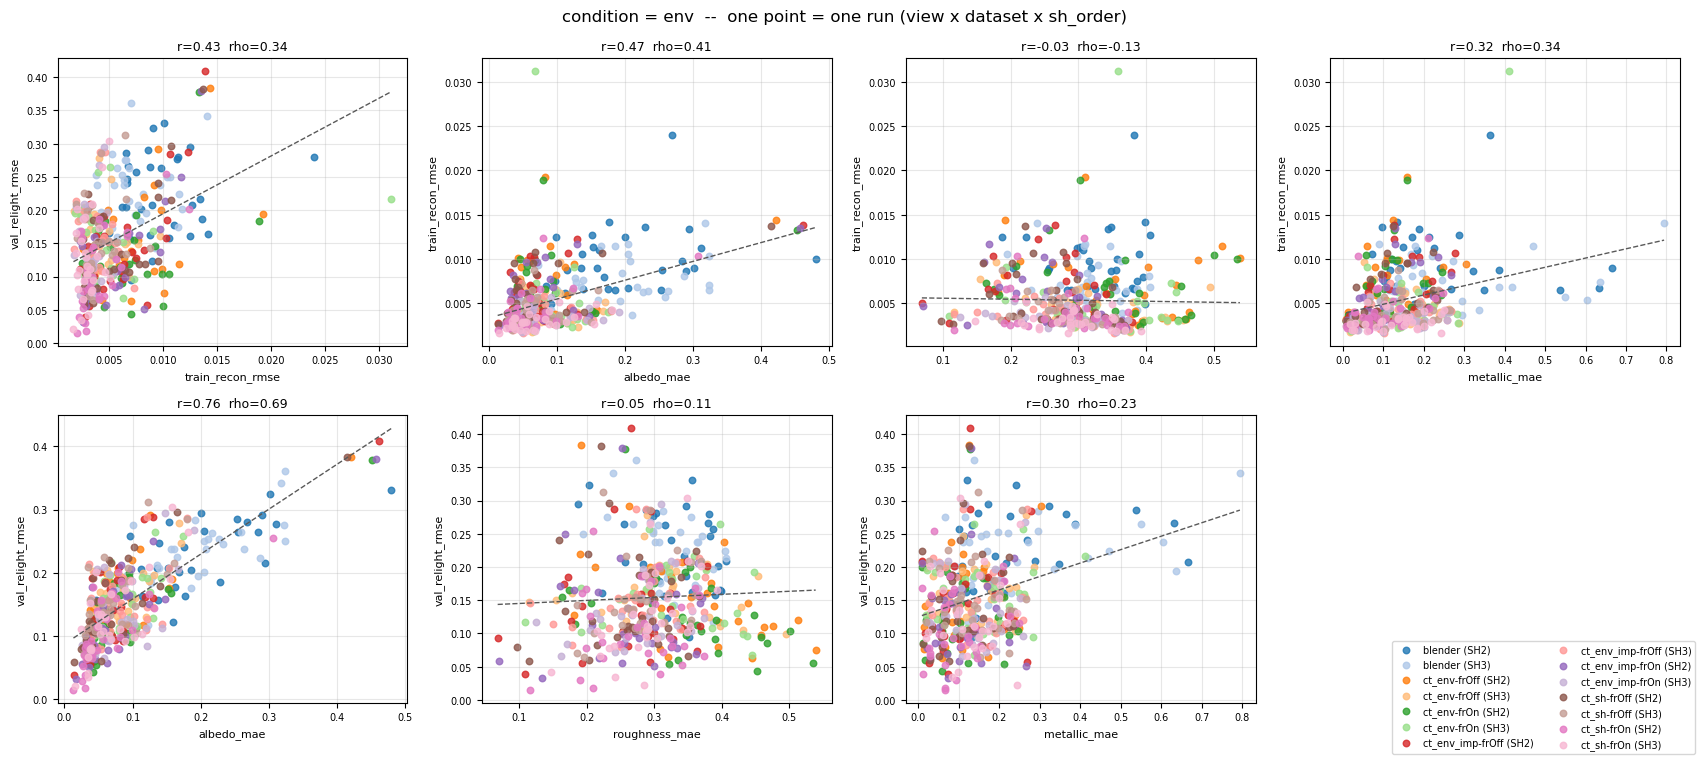

=== condition = env_ground  (n_runs=480) ===
                                           n  pearson_r  p_pearson  spearman_rho  p_spearman
pair                                                                                        
train_recon_rmse  <->  val_relight_rmse  480     0.4323     0.0000        0.3450      0.0000
albedo_mae  <->  train_recon_rmse        480     0.4513     0.0000        0.5100      0.0000
roughness_mae  <->  train_recon_rmse     480     0.1299     0.0044        0.0334      0.4654
metallic_mae  <->  train_recon_rmse      480     0.2035     0.0000        0.3869      0.0000
albedo_mae  <->  val_relight_rmse        480     0.5122     0.0000        0.4936      0.0000
roughness_mae  <->  val_relight_rmse     480     0.5028     0.0000        0.5288      0.0000
metallic_mae  <->  val_relight_rmse      480     0.5627     0.0000        0.5080      0.0000 



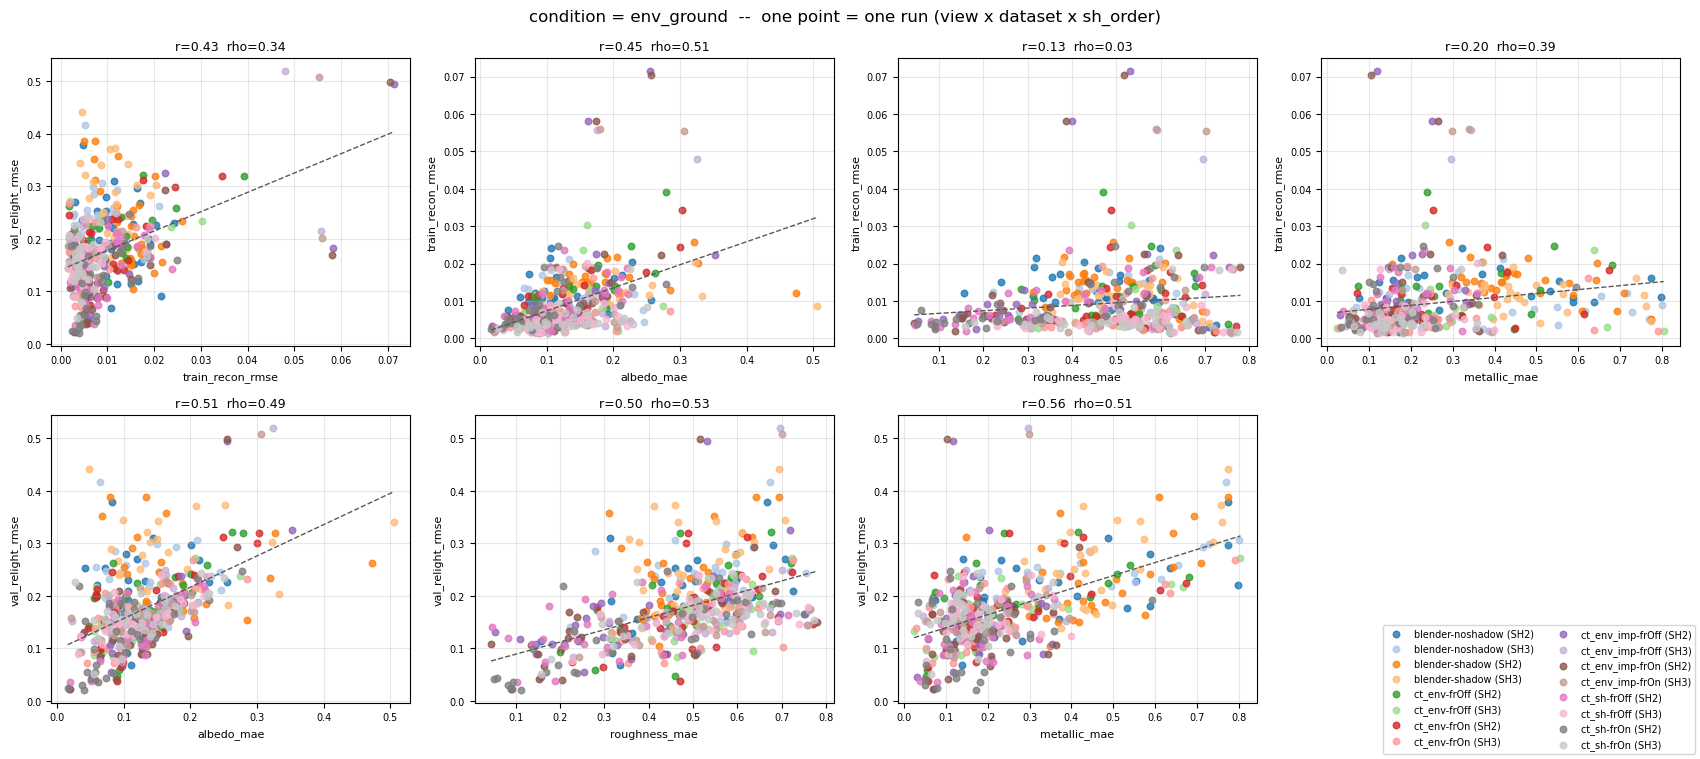

=== within-label Spearman (mean +/- std over labels) ===
                                         n_labels  n_runs  mean_spearman_rho  std_spearman_rho
pair                                                                                          
train_recon_rmse  <->  val_relight_rmse        18     900             0.0808            0.3113
albedo_mae  <->  train_recon_rmse              18     900             0.4115            0.1608
roughness_mae  <->  train_recon_rmse           18     900             0.0275            0.2205
metallic_mae  <->  train_recon_rmse            18     900             0.1790            0.2700
albedo_mae  <->  val_relight_rmse              18     900             0.4438            0.2758
roughness_mae  <->  val_relight_rmse           18     900             0.2933            0.2707
metallic_mae  <->  val_relight_rmse            18     900             0.2875            0.1709


In [6]:
# -- correlations: recon / relight / intrinsics MAE ----------------------------
from scipy.stats import pearsonr, spearmanr

RECON, RELIGHT = 'train_recon_rmse', 'val_relight_rmse'
PAIRS = ([(RECON, RELIGHT)]
         + [(m, RECON) for m in INTRINSIC_MAES]
         + [(m, RELIGHT) for m in INTRINSIC_MAES])


def _corr(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    if len(x) < 3 or x.std() == 0 or y.std() == 0:
        return dict(n=len(x), pearson_r=np.nan, p_pearson=np.nan,
                    spearman_rho=np.nan, p_spearman=np.nan)
    pr, pp = pearsonr(x, y)
    sr, sp = spearmanr(x, y)
    return dict(n=len(x), pearson_r=pr, p_pearson=pp, spearman_rho=sr, p_spearman=sp)


def corr_table(df, name):
    rows = [dict(pair=f'{a}  <->  {b}', **_corr(df[a], df[b]))
            for a, b in PAIRS if a in df and b in df]
    t = pd.DataFrame(rows).set_index('pair')
    print(f'=== {name}  (n_runs={len(df)}) ===')
    print(t.round(4).to_string(), '\n')
    return t


def corr_scatter(df, name):
    fig, axes = plt.subplots(2, 4, figsize=(17, 7.6))
    labels = sorted(df['label'].unique())
    cmap = plt.get_cmap('tab10' if len(labels) <= 10 else 'tab20')
    colors = {lb: cmap(i % cmap.N) for i, lb in enumerate(labels)}
    for ax, (a, b) in zip(axes.flat, PAIRS):
        sub = df[[a, b, 'label']].replace([np.inf, -np.inf], np.nan).dropna()
        for lb in labels:
            s = sub[sub['label'] == lb]
            if len(s):
                ax.scatter(s[a], s[b], s=22, alpha=0.8, color=colors[lb], label=lb)
        c = _corr(sub[a], sub[b])
        if len(sub) >= 2 and sub[a].std() > 0:      # least-squares guide line
            m, q = np.polyfit(sub[a], sub[b], 1)
            xs = np.linspace(sub[a].min(), sub[a].max(), 10)
            ax.plot(xs, m * xs + q, lw=1, color='0.35', ls='--')
        ax.set_xlabel(a, fontsize=8); ax.set_ylabel(b, fontsize=8)
        ax.set_title(f"r={c['pearson_r']:.2f}  rho={c['spearman_rho']:.2f}", fontsize=9)
        ax.grid(alpha=0.3); ax.tick_params(labelsize=7)
    for ax in axes.flat[len(PAIRS):]:
        ax.set_visible(False)
    h, l = axes.flat[0].get_legend_handles_labels()
    fig.legend(h, l, loc='lower right', fontsize=7, ncol=2, frameon=True)
    fig.suptitle(f'{name}  --  one point = one run (view x dataset x sh_order)', fontsize=12)
    plt.tight_layout(); plt.show()


# overall + per condition
corr_table(df_runs, 'ALL runs')
corr_scatter(df_runs, 'ALL runs')
for _cond in ['env', 'env_ground']:
    _dfc = df_runs[df_runs['condition'] == _cond]
    if len(_dfc):
        corr_table(_dfc, f'condition = {_cond}')
        corr_scatter(_dfc, f'condition = {_cond}')

# within-label (pooled across views): removes the between-dataset spread, which
# on its own can create a correlation even if nothing co-varies inside a setting.
_wrows = []
for a, b in PAIRS:
    if a not in df_runs or b not in df_runs:
        continue
    rs, ns = [], 0
    for _, g in df_runs.groupby('label'):
        c = _corr(g[a], g[b])
        if np.isfinite(c['spearman_rho']):
            rs.append(c['spearman_rho']); ns += c['n']
    _wrows.append(dict(pair=f'{a}  <->  {b}', n_labels=len(rs), n_runs=ns,
                       mean_spearman_rho=np.mean(rs) if rs else np.nan,
                       std_spearman_rho=np.std(rs) if rs else np.nan))
print('=== within-label Spearman (mean +/- std over labels) ===')
print(pd.DataFrame(_wrows).set_index('pair').round(4).to_string())
